In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

In [2]:
#connect to postgreSQL

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

In [3]:
df = pd.read_sql("SELECT * FROM orders_clean", engine)

In [4]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,profit_margin
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.1600
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.3000
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.4700
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,-0.4000
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.1125


In [5]:
df.describe()

,row_id,order_date,postal_code,sales,quantity,discount,profit,year,month,profit_margin
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,0.120314
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-2.750000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,0.075000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,0.270000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,0.362500
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,0.500000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,0.466754


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   str           
 2   order_date     9994 non-null   datetime64[us]
 3   ship_date      9994 non-null   str           
 4   ship_mode      9994 non-null   str           
 5   customer_id    9994 non-null   str           
 6   customer_name  9994 non-null   str           
 7   segment        9994 non-null   str           
 8   country        9994 non-null   str           
 9   city           9994 non-null   str           
 10  state          9994 non-null   str           
 11  postal_code    9994 non-null   int64         
 12  region         9994 non-null   str           
 13  product_id     9994 non-null   str           
 14  category       9994 non-null   str           
 15  sub-category   9994 non-null   s

In [7]:
# Feature engineering
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["profit_margin"] = df["profit"] / df["sales"]
df["profitable"] = (df["profit"] > 0).astype(int)

print(f"Shape : {df.shape}")
print(f"Columns : {df.columns.to_list}")

Shape : (9994, 25)
Columns : <bound method IndexOpsMixin.tolist of Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit', 'year',
       'month', 'profit_margin', 'profitable'],
      dtype='str')>


In [8]:
df[['sales', 'discount', 'profit', 'profit_margin']].describe().round(2)

,sales,discount,profit,profit_margin
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,0.16,28.66,0.12
std,623.25,0.21,234.26,0.47
min,0.44,0.00,-6599.98,-2.75
25%,17.28,0.00,1.73,0.08
50%,54.49,0.20,8.67,0.27
75%,209.94,0.20,29.36,0.36
max,22638.48,0.80,8399.98,0.50


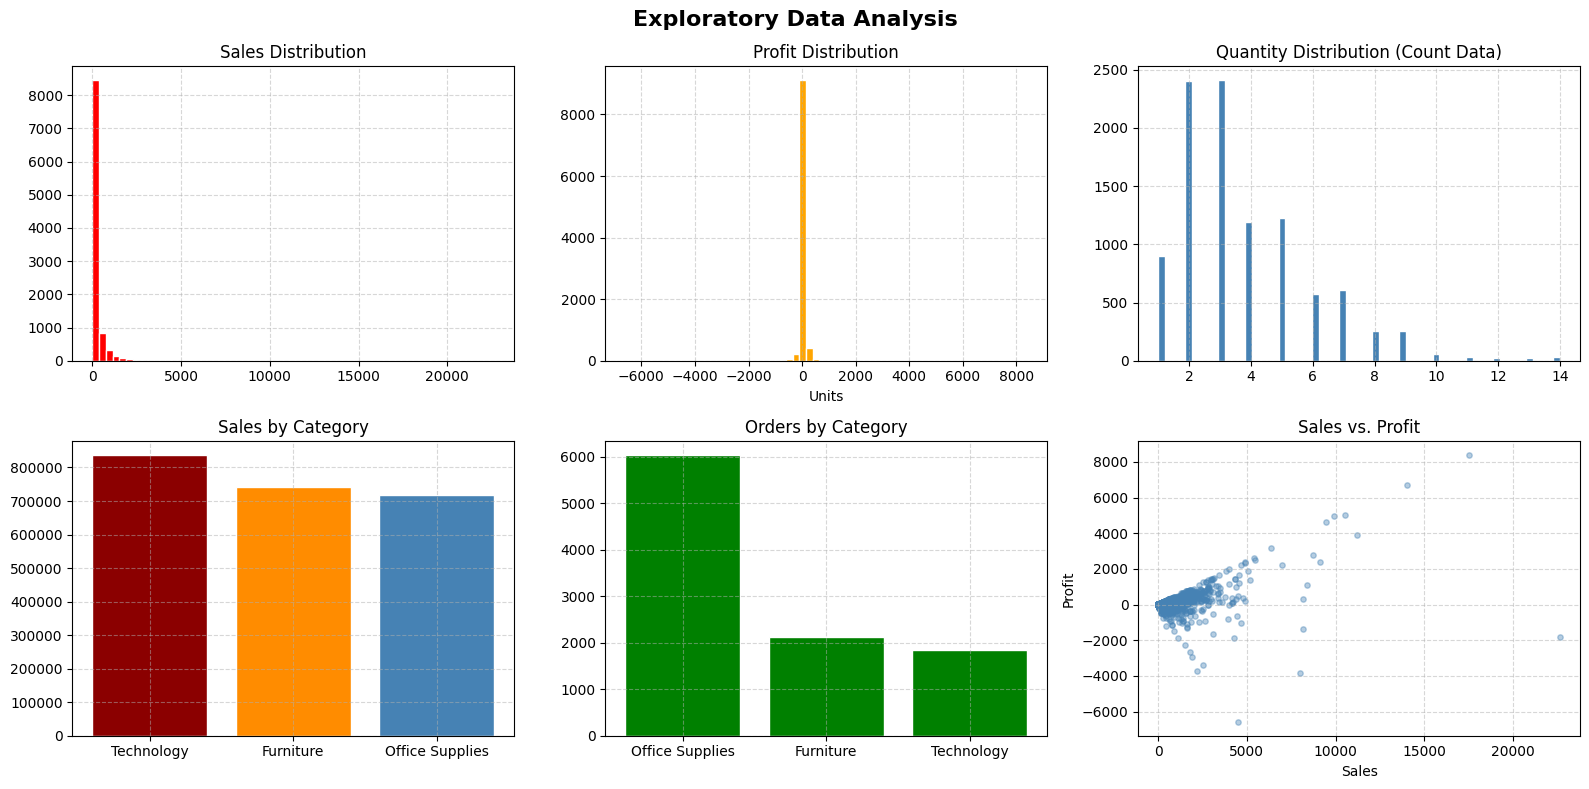

EDA complete


In [9]:
#EDA plots
fig, axes = plt.subplots(2,3, figsize=(16, 8))
fig.suptitle('Exploratory Data Analysis', fontsize = 16, fontweight = 'bold')
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.5)

axes[0,0].hist(df['sales'], bins = 60, color='red', edgecolor='white')
axes[0,0].set_title('Sales Distribution') ; axes[0,1].set_xlabel('Sales (£)')

axes[0,1].hist(df['profit'], bins = 60, color='orange', edgecolor='white')
axes[0,1].set_title('Profit Distribution') ; axes[0,1].set_xlabel('Profit (£)')

axes[0,2].hist(df['quantity'], bins = 60, color='steelblue', edgecolor='white')
axes[0,2].set_title('Quantity Distribution (Count Data)') ; axes[0,1].set_xlabel('Units')

sales_by_cat = df.groupby("category")["sales"].sum().sort_values(ascending=False)
axes[1,0].bar(sales_by_cat.index, sales_by_cat.values, color=['darkred', 'darkorange', 'steelblue'], edgecolor='white')
axes[1,0].set_title('Sales by Category')

orders_by_cat = df['category'].value_counts()
axes[1,1].bar(orders_by_cat.index, orders_by_cat.values, color='green', edgecolor='white')
axes[1,1].set_title("Orders by Category")

axes[1,2].scatter(df['sales'], df['profit'], alpha=0.4, color='steelblue', s=15)
axes[1,2].set_title('Sales vs. Profit'); axes[1,2].set_xlabel('Sales'); axes[1,2].set_ylabel('Profit')

plt.tight_layout()
plt.show()
print('EDA complete')
